In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from pylab import rcParams
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [21]:
X, y = make_circles(n_samples = 200, noise = 0.1, random_state = 1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [23]:
model = Sequential()

model.add(Dense(256, input_dim = 2, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [24]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [30]:
callbacks = EarlyStopping(
    monitor = "val_loss",
    min_delta = 0.00001,
    patience = 20,
    verbose = 1,
    mode = "auto",
    baseline = None,
    restore_best_weights = True
)

In [31]:
history = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 300, callbacks = callbacks)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8497 - loss: 0.3262 - val_accuracy: 0.9250 - val_loss: 0.3020
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8522 - loss: 0.3278 - val_accuracy: 0.9250 - val_loss: 0.3025
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8790 - loss: 0.3089 - val_accuracy: 0.9250 - val_loss: 0.2992
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8566 - loss: 0.3317 - val_accuracy: 0.9250 - val_loss: 0.3025
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8445 - loss: 0.3190 - val_accuracy: 0.9250 - val_loss: 0.3002
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8604 - loss: 0.3210 - val_accuracy: 0.9250 - val_loss: 0.2990
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8591 - loss: 0.3249 - val_accuracy: 0.9250 - val_loss: 0.2989
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8644 - loss: 0.3175 - val_accuracy: 0.9250 - val_loss:

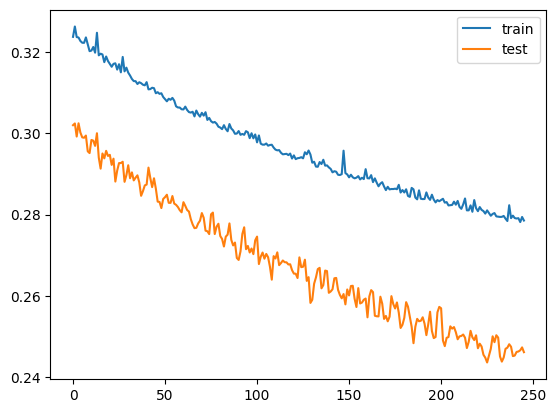

In [32]:
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')

plt.legend()
plt.show()